1. What are cells tuned to? As in: is the whole escape sequence tiled uniformly?

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may] # 

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may", "JAL8_flip4_10may", "JAL8_14may"] # 

In [2]:
%load_ext autoreload
from behave_analysis.process.process import Process
from behave_analysis.utils.creating_directories import make_directory

import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [10]:
"""Load in data from homing/escape analysis"""
%autoreload 2

compression = ['bird_dist_shelter', 'full_distance_shelter', 'escape']
compression = ['bird_dist_shelter', 'escape']

c_names = ['shelter_only', 'barrier', 'flipped_barrier']

full_dict = {}
sig_cell_dict = {}
cell_tuning_dict = {}

for comp in compression:

    # print(comp)

    full_dict[comp] = {'shelter_only': [],
                        'barrier': [],
                        'flipped_barrier': []}
    
    sesh_names = []
    all_sig_cells = []
    cell_tuning = []

    for exp in experiments_objects:

        # print(exp.nick_name + '_' + exp.experiment_date)

        # load data
        nickname = exp.nick_name + '_' + exp.experiment_date
        sesh_names.append(nickname)
        exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp

        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
        saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
        data = np.load(saving_file)

        # pull out the paramas
        data_files = data.files
        if 'params_real' in data_files:
            params_real = data['params_real']
            params_shifts = data['params_shifts']
        else:
            params_real = data["arr_12"]
            params_shifts = data["arr_1"]
        
        # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
        # tuning = params_real[:,:,1]
        sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)
        if len(all_sig_cells) == 0:
            all_sig_cells = sig_cells
            cell_tuning = params_real
            sesh_vector = np.ones(sig_cells.shape[0])
        else:
            all_sig_cells = np.vstack((all_sig_cells, sig_cells))
            cell_tuning = np.vstack((cell_tuning, params_real))
            sesh_vector = np.hstack((sesh_vector, np.ones(sig_cells.shape[0]) * (sesh_vector[-1]+1)))
    
    sig_cell_dict[comp] = all_sig_cells
    cell_tuning_dict[comp] = cell_tuning

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_20500\2654242262.py:16: RuntimeWarning: invalid value encountered in divide
  hist = hist/len(tuning[:,idx])


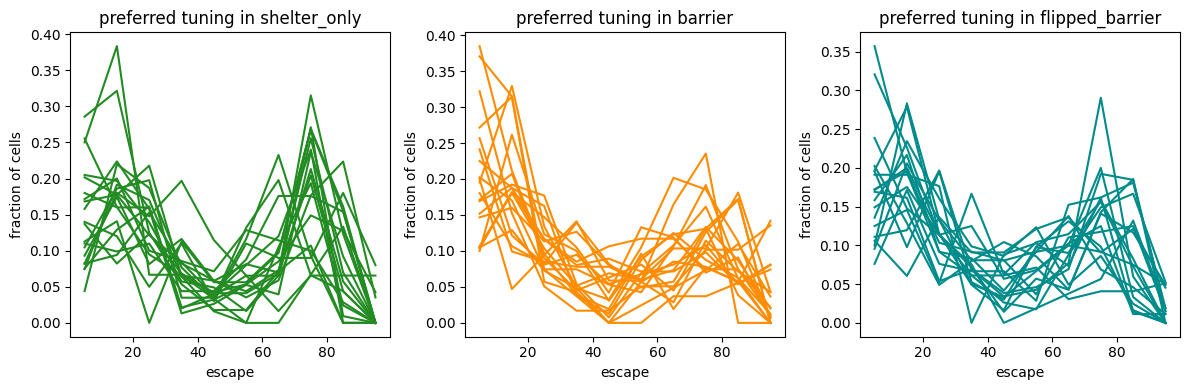

In [22]:
"""Histogram of preferred comp variable"""

comp = 'escape'
colors = ['#228B22','#FF8C00','#008B8B']
fig, axs = plt.subplots(1,3,figsize = (12,4))
bins = np.arange(0,101,10)

# iterate over sessions
for s in np.unique(sesh_vector):
    this_tuning = cell_tuning_dict[comp][sesh_vector == s, :, 1]
    this_sig = sig_cell_dict[comp][sesh_vector == s, :]
    # iterate over conditions
    for idx, c in enumerate(c_names):
        tuning = this_tuning[this_sig[:,idx] == 1,:]
        hist,_ = np.histogram(tuning[:,idx], bins = bins)
        hist = hist/len(tuning[:,idx])
        axs[idx].plot(bins[:-1] + 5, hist, color = colors[idx])

for idx, c in enumerate(c_names):
    axs[idx].set_title('preferred tuning in ' + c)
    axs[idx].set_xlabel(comp)
    axs[idx].set_ylabel('fraction of cells')       

plt.tight_layout() 

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_20500\3258095824.py:41: RuntimeWarning: Mean of empty slice
  avg_sigma[b] = np.nanmean(sigma[(mu > bins[b]) & (mu <= bins[b+1])])


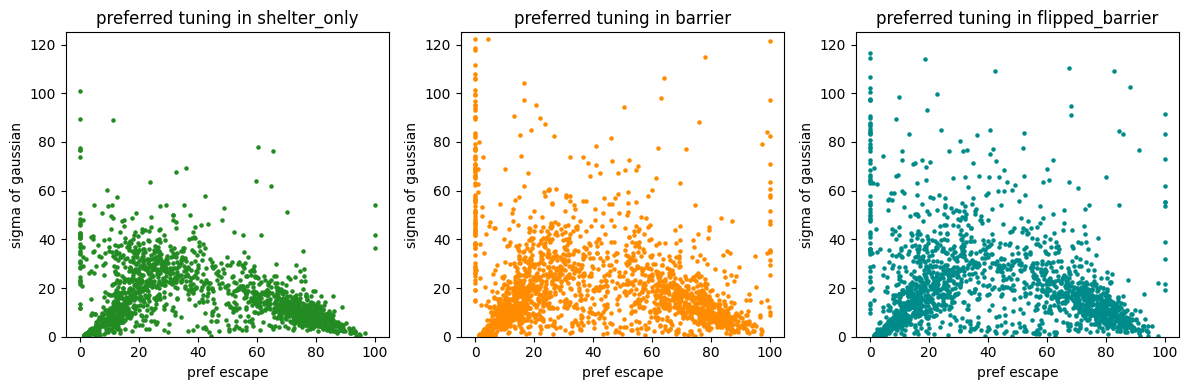

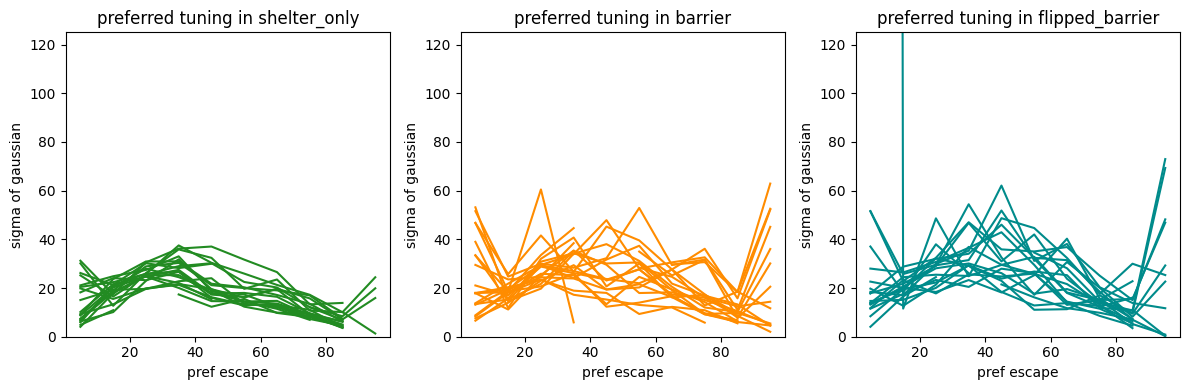

In [26]:
"""Comparing mu and sigma of tuned cells"""

comp = 'escape'
colors = ['#228B22','#FF8C00','#008B8B']
fig, axs = plt.subplots(1,3,figsize = (12,4))

# iterate over sessions
for s in np.unique(sesh_vector):
    this_sigma = cell_tuning_dict[comp][sesh_vector == s, :, 2]
    this_mu = cell_tuning_dict[comp][sesh_vector == s, :, 1]
    this_sig = sig_cell_dict[comp][sesh_vector == s, :]
    # iterate over conditions
    for idx, c in enumerate(c_names):
        sigma = this_sigma[this_sig[:,idx] == 1,:]
        mu = this_mu[this_sig[:,idx] == 1,:]
        axs[idx].scatter(mu[:,idx], sigma[:,idx], s = 5, c = colors[idx])

for idx, c in enumerate(c_names):
    axs[idx].set_title('preferred tuning in ' + c)
    axs[idx].set_xlabel('pref ' + comp)
    axs[idx].set_ylabel('sigma of gaussian')       
    axs[idx].set_ylim(0,125)

plt.tight_layout() 

fig, axs = plt.subplots(1,3,figsize = (12,4))
bins = np.arange(0,101,10)

# iterate over sessions
for s in np.unique(sesh_vector):
    this_sigma = cell_tuning_dict[comp][sesh_vector == s, :, 2]
    this_mu = cell_tuning_dict[comp][sesh_vector == s, :, 1]
    this_sig = sig_cell_dict[comp][sesh_vector == s, :]
    # iterate over conditions
    for idx, c in enumerate(c_names):
        sigma = this_sigma[this_sig[:,idx] == 1,idx]
        mu = this_mu[this_sig[:,idx] == 1,idx]
        avg_sigma = np.zeros(len(bins)-1)
        for b,_ in enumerate(bins[:-1]):
            # TODO: plot the average mu to sigma for each session!
            avg_sigma[b] = np.nanmean(sigma[(mu > bins[b]) & (mu <= bins[b+1])])
        axs[idx].plot(bins[:-1] + 5, avg_sigma, color = colors[idx])
        
for idx, c in enumerate(c_names):
    axs[idx].set_title('preferred tuning in ' + c)
    axs[idx].set_xlabel('pref ' + comp)
    axs[idx].set_ylabel('sigma of gaussian')       
    axs[idx].set_ylim(0,125)

plt.tight_layout() 

In [23]:
"""Compare to tuning to shelter distance (bird's flight) in exploration"""
"""Load in data from explore analysis"""
%autoreload 2

compression = ['bird_dist_shelter']

c_names = ['shelter_only', 'barrier', 'flipped_barrier']

exp_full_dict = {}
exp_sig_cell_dict = {}
exp_cell_tuning_dict = {}

for comp in compression:

    # print(comp)

    exp_full_dict[comp] = {'shelter_only': [],
                        'barrier': [],
                        'flipped_barrier': []}
    
    exp_sesh_names = []
    exp_all_sig_cells = []
    exp_cell_tuning = []

    for exp in experiments_objects:

        # print(exp.nick_name + '_' + exp.experiment_date)

        # load data
        nickname = exp.nick_name + '_' + exp.experiment_date
        exp_sesh_names.append(nickname)
        exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp

        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
        saving_file = dump_path + exp_nickname + '_Tuning.npz'
        data = np.load(saving_file)

        # pull out the paramas
        data_files = data.files
        if 'params_real' in data_files:
            params_real = data['params_real']
            params_shifts = data['params_shifts']
        else:
            params_real = data["arr_12"]
            params_shifts = data["arr_1"]
        
        # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
        # exp_tuning = params_real[:,:,1]
        exp_sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)
        if len(exp_all_sig_cells) == 0:
            exp_all_sig_cells = exp_sig_cells
            exp_cell_tuning = params_real
            exp_sesh_vector = np.ones(exp_sig_cells.shape[0])
        else:
            exp_all_sig_cells = np.vstack((exp_all_sig_cells, exp_sig_cells))
            exp_cell_tuning = np.vstack((exp_cell_tuning, params_real))
            exp_sesh_vector = np.hstack((exp_sesh_vector, np.ones(exp_sig_cells.shape[0]) * (exp_sesh_vector[-1]+1)))

    exp_sig_cell_dict[comp] = exp_all_sig_cells
    exp_cell_tuning_dict[comp] = exp_cell_tuning

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_20500\3874588950.py:16: RuntimeWarning: invalid value encountered in divide
  hist = hist/len(tuning[:,idx])


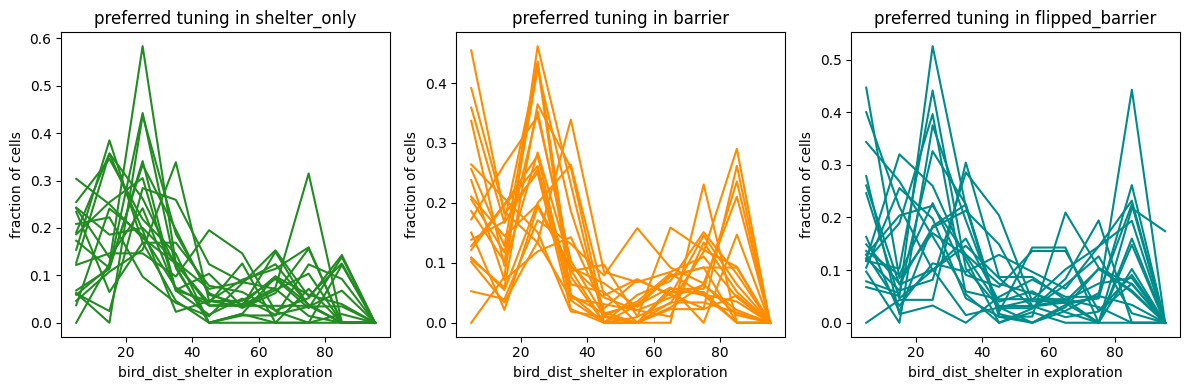

In [25]:
"""Histogram of preferred comp variable"""

comp = 'bird_dist_shelter'
colors = ['#228B22','#FF8C00','#008B8B']
fig, axs = plt.subplots(1,3,figsize = (12,4))
bins = np.arange(0,101,10)

# iterate over sessions
for s in np.unique(sesh_vector):
    this_tuning = exp_cell_tuning_dict[comp][sesh_vector == s, :, 1]
    this_sig = exp_sig_cell_dict[comp][sesh_vector == s, :]
    # iterate over conditions
    for idx, c in enumerate(c_names):
        tuning = this_tuning[this_sig[:,idx] == 1,:]
        hist,_ = np.histogram(tuning[:,idx], bins = bins)
        hist = hist/len(tuning[:,idx])
        axs[idx].plot(bins[:-1] + 5, hist, color = colors[idx])

for idx, c in enumerate(c_names):
    axs[idx].set_title('preferred tuning in ' + c)
    axs[idx].set_xlabel(comp + ' in exploration')
    axs[idx].set_ylabel('fraction of cells')       

plt.tight_layout() 